# Data exploration

In [25]:
%load_ext autoreload
%autoreload 2

import aribu            # GDAL fix, please keep this as the first import

from pprint import pprint
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
import numpy as np
import pandas as pd
import rasterio
from shapely.geometry import box
from skimage.filters import threshold_otsu

from aribu.paths import *
from aribu.dataset import *
from aribu.viz import *

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 1. Examine a typical S1 chip

First, let us look at a typical chip (and its label):

In [26]:
chip_id = "Mekong_922373"
s1_path = S1_DIR / f"{chip_id}_S1Hand.tif"
label_path = LABEL_DIR / f"{chip_id}_LabelHand.tif"

print(f"S1 path:    {s1_path}")
print(f"Label path: {label_path}")

S1 path:    C:\Dev\Projects\Aribu\data\raw\HandLabeled\S1Hand\Mekong_922373_S1Hand.tif
Label path: C:\Dev\Projects\Aribu\data\raw\HandLabeled\LabelHand\Mekong_922373_LabelHand.tif


### 1.1 Meta data of the chip

In [27]:
with rasterio.open(s1_path) as src:
    print(f"bands:      {src.count}")
    print(f"dtypes:     {src.dtypes}")
    print(f"shape:      {src.shape}      (rows, cols)")
    print(f"crs:        {src.crs}")
    print(f"nodata:     {src.nodata}")
    print(f"bounds:     {src.bounds}")
    print(f"transform:\n{src.transform}")
    s1_profile = src.profile

print("\nprofile:")
pprint(dict(s1_profile))

bands:      2
dtypes:     ('float32', 'float32')
shape:      (512, 512)      (rows, cols)
crs:        EPSG:4326
nodata:     nan
bounds:     BoundingBox(left=105.96958282810253, bottom=12.188341774933667, right=106.01557657064946, top=12.234335517480586)
transform:
| 0.00, 0.00, 105.97|
| 0.00,-0.00, 12.23|
| 0.00, 0.00, 1.00|

profile:
{'blockxsize': 512,
 'blockysize': 512,
 'compress': 'deflate',
 'count': 2,
 'crs': CRS.from_wkt('GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST],AUTHORITY["EPSG","4326"]]'),
 'driver': 'GTiff',
 'dtype': 'float32',
 'height': 512,
 'interleave': 'band',
 'nodata': nan,
 'tiled': False,
 'transform': Affine(8.983152841195215e-05, 0.0, 105.96958282810253,
       0.0, -8.983152841195215e-05, 12.234335517480586),
 'width': 512}


In [28]:
with rasterio.open(s1_path) as src:
    stack = src.read()          # all bands -> (bands, rows, cols)
    vv = src.read(VV_BAND)      # one band  -> (rows, cols)
    vh = src.read(VH_BAND)

print(f"stack.shape: {stack.shape}")
print(f"vv.shape:    {vv.shape}")
print(f"vh.shape:    {vh.shape}")

np.testing.assert_array_equal(stack[0], vv)
np.testing.assert_array_equal(stack[1], vh)

print("\nconfirmed: src.read(1) == stack[0] == vv")
print("           src.read(2) == stack[1] == vh")

stack.shape: (2, 512, 512)
vv.shape:    (512, 512)
vh.shape:    (512, 512)

confirmed: src.read(1) == stack[0] == vv
           src.read(2) == stack[1] == vh


Note that the bands and the label are all numpy n-dimensional arrays:

In [29]:
type(stack), type(vv), type(vh)

(numpy.ndarray, numpy.ndarray, numpy.ndarray)

### 1.2 Meta data of the label

In [30]:
with rasterio.open(label_path) as src:
    print(f"bands:      {src.count}")
    print(f"dtypes:     {src.dtypes}")
    print(f"shape:      {src.shape}      (rows, cols)")
    print(f"crs:        {src.crs}")
    print(f"nodata:     {src.nodata}")
    print(f"bounds:     {src.bounds}")
    print(f"transform:\n{src.transform}")
    label_profile = src.profile
    label = src.read(1)

print("\nprofile:")
pprint(dict(label_profile))

bands:      1
dtypes:     ('int16',)
shape:      (512, 512)      (rows, cols)
crs:        EPSG:4326
nodata:     None
bounds:     BoundingBox(left=105.96958282810253, bottom=12.188341774933663, right=106.01557657064946, top=12.234335517480586)
transform:
| 0.00, 0.00, 105.97|
| 0.00,-0.00, 12.23|
| 0.00, 0.00, 1.00|

profile:
{'blockxsize': 512,
 'blockysize': 512,
 'compress': 'deflate',
 'count': 1,
 'crs': CRS.from_wkt('GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST],AUTHORITY["EPSG","4326"]]'),
 'driver': 'GTiff',
 'dtype': 'int16',
 'height': 512,
 'interleave': 'band',
 'nodata': None,
 'tiled': False,
 'transform': Affine(8.983152841195857e-05, 0.0, 105.96958282810253,
       0.0, -8.983152841195857e-05, 12.234335517480586),
 'width': 512}


### 1.3 Statistics

In [31]:
print(f"naive min/max:      {stack.min():.2f} / {stack.max():.2f}")
print(f"nan-aware min/max:  {np.nanmin(stack):.2f} / {np.nanmax(stack):.2f}")

n_nan = np.isnan(stack).sum()
print(f"\nNaN pixels: {n_nan:,} of {stack.size:,} ({n_nan / stack.size:.1%})")

for name, band in (("VV", vv), ("VH", vh)):
    valid = np.isfinite(band)
    print(f"{name}: {valid.sum():>7,} valid px ({valid.mean():.1%}), "
          f"range {band[valid].min():7.2f} to {band[valid].max():6.2f} dB, "
          f"median {np.median(band[valid]):7.2f} dB")

naive min/max:      -51.15 / 9.00
nan-aware min/max:  -51.15 / 9.00

NaN pixels: 0 of 524,288 (0.0%)
VV: 262,144 valid px (100.0%), range  -34.69 to   9.00 dB, median  -10.13 dB
VH: 262,144 valid px (100.0%), range  -51.15 to  -5.97 dB, median  -16.67 dB


Here the naive and nan-aware mins/maxes agree due to absent of NaN pixels. We will see later that it is important to use nan-aware functions.

In [32]:
LABEL_NAMES = {LABEL_NODATA: "no data", LABEL_LAND: "land", LABEL_WATER: "water"}

values, counts = np.unique(label, return_counts=True)
print("numerical label:")
for value, count in zip(values, counts, strict=True):
    print(f"                {value:>3}  {LABEL_NAMES[value]:>7}: {count:>7,} px  "
          f"({count / label.size:5.4%} of chip)")

labelled = label != LABEL_NODATA
water_share = (label == LABEL_WATER).sum() / labelled.sum()
print(f"\nwater as a share of labelled pixels: {water_share:.1%}")
print(f"predict no water everywhere would score "
      f"{(label == LABEL_LAND).sum() / labelled.sum():.1%} accuracy")

numerical label:
                 -1  no data:       6 px  (0.0023% of chip)
                  0     land: 142,373 px  (54.3110% of chip)
                  1    water: 119,765 px  (45.6867% of chip)

water as a share of labelled pixels: 45.7%
predict no water everywhere would score 54.3% accuracy


### 1.4 Visualization

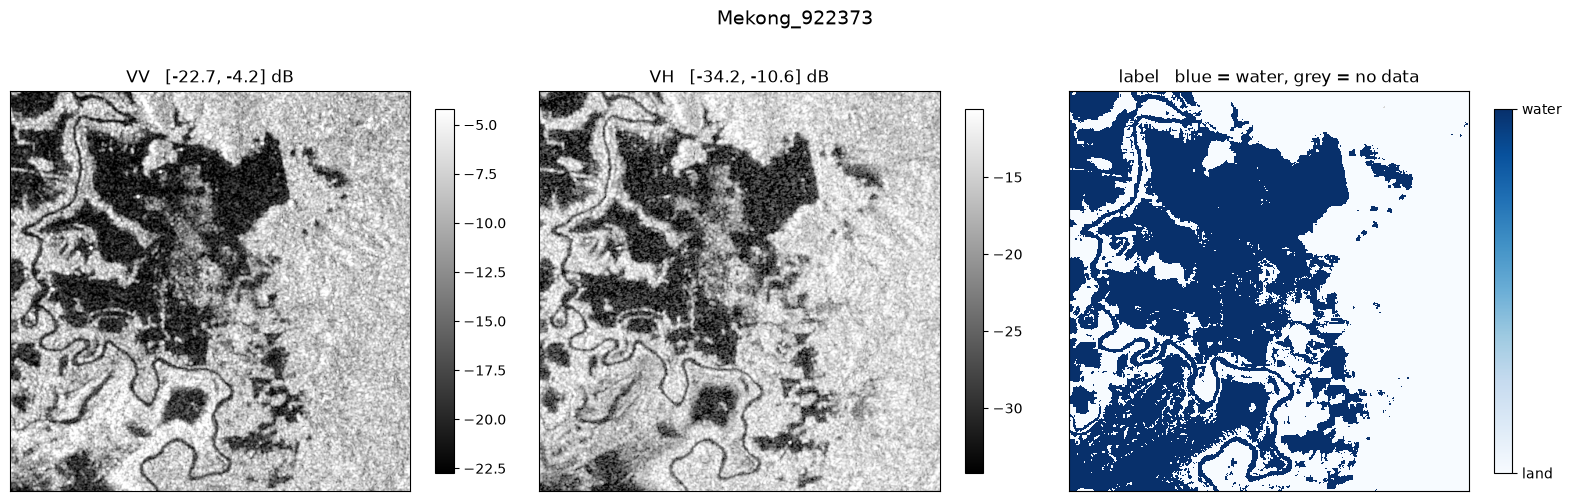

In [33]:
label_display = np.ma.masked_where(label == LABEL_NODATA, label)

fig, axes = plt.subplots(1, 3, figsize=(16, 5.5))

for ax, band, name in zip(axes[:2], (vv, vh), ("VV", "VH"), strict=True):
    vmin, vmax = percentile_limits(band)
    im = ax.imshow(band, cmap="gray", vmin=vmin, vmax=vmax)
    ax.set_title(f"{name}   [{vmin:.1f}, {vmax:.1f}] dB")
    fig.colorbar(im, ax=ax, shrink=0.75)

# interpolation="nearest" because the label is categorical
im = axes[2].imshow(label_display, cmap=LABEL_CMAP,
                    vmin=LABEL_LAND, vmax=LABEL_WATER, interpolation="nearest")
axes[2].set_title("label   blue = water, grey = no data")
cbar = fig.colorbar(im, ax=axes[2], shrink=0.75, ticks=[LABEL_LAND, LABEL_WATER])
cbar.ax.set_yticklabels([LABEL_NAMES[LABEL_LAND], LABEL_NAMES[LABEL_WATER]])

for ax in axes:
    ax.set_xticks([])
    ax.set_yticks([])

fig.suptitle(chip_id, fontsize=14)
fig.tight_layout()
plt.show()

Note that we have normalized the grey/color scales above, separately for each band. In general for the same chip the VV band is brighter than the VH band:

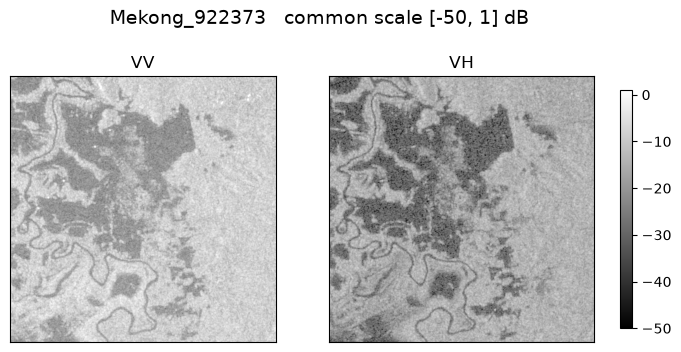

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(11*0.75, 5.5*0.75))

for ax, band, name in zip(axes, (vv, vh), ("VV", "VH"), strict=True):
    im = ax.imshow(band, cmap="gray", vmin=CLIP_LO, vmax=CLIP_HI)
    ax.set_title(name)
    ax.set_xticks([])
    ax.set_yticks([])

# one colorbar, because both panels now share the scale
fig.colorbar(im, ax=axes, shrink=0.75, fraction=0.046, pad=0.04)
fig.suptitle(f"{chip_id}   common scale [{CLIP_LO:.0f}, {CLIP_HI:.0f}] dB", fontsize=14)
plt.show()

## 2. Some chips are odd

In [35]:
chip_id = "Bolivia_103757"
s1_path = S1_DIR / f"{chip_id}_S1Hand.tif"
label_path = LABEL_DIR / f"{chip_id}_LabelHand.tif"

print(f"S1 path:    {s1_path}")
print(f"Label path: {label_path}")

with rasterio.open(s1_path) as src:
    stack = src.read()
    vv = src.read(VV_BAND)
    vh = src.read(VH_BAND)

with rasterio.open(label_path) as src:
    label_profile = src.profile
    label = src.read(1)

S1 path:    C:\Dev\Projects\Aribu\data\raw\HandLabeled\S1Hand\Bolivia_103757_S1Hand.tif
Label path: C:\Dev\Projects\Aribu\data\raw\HandLabeled\LabelHand\Bolivia_103757_LabelHand.tif


In [36]:
print(f"naive min/max:      {stack.min():.2f} / {stack.max():.2f}")
print(f"nan-aware min/max:  {np.nanmin(stack):.2f} / {np.nanmax(stack):.2f}")

n_nan = np.isnan(stack).sum()
print(f"\nNaN pixels: {n_nan:,} of {stack.size:,} ({n_nan / stack.size:.1%})")

for name, band in (("VV", vv), ("VH", vh)):
    valid = np.isfinite(band)
    print(f"{name}: {valid.sum():>7,} valid px ({valid.mean():.1%}), "
          f"range {band[valid].min():7.2f} to {band[valid].max():6.2f} dB, "
          f"median {np.median(band[valid]):7.2f} dB")

naive min/max:      nan / nan
nan-aware min/max:  -48.25 / -0.69

NaN pixels: 321,042 of 524,288 (61.2%)
VV: 101,623 valid px (38.8%), range  -40.82 to  -0.69 dB, median  -11.73 dB
VH: 101,623 valid px (38.8%), range  -48.25 to  -6.99 dB, median  -17.58 dB


**About 61% of the total pixels in the VV and VH bands are missing values!**

In [37]:
LABEL_NAMES = {LABEL_NODATA: "no data", LABEL_LAND: "land", LABEL_WATER: "water"}

values, counts = np.unique(label, return_counts=True)
print("numerical label:")
for value, count in zip(values, counts, strict=True):
    print(f"                {value:>3}  {LABEL_NAMES[value]:>7}: {count:>7,} px  "
          f"({count / label.size:5.4%} of chip)")

labelled = label != LABEL_NODATA
water_share = (label == LABEL_WATER).sum() / labelled.sum()
print(f"\nwater as a share of labelled pixels: {water_share:.1%}")
print(f"predict no water everywhere would score "
      f"{(label == LABEL_LAND).sum() / labelled.sum():.1%} accuracy")

numerical label:
                 -1  no data: 174,067 px  (66.4013% of chip)
                  0     land:  52,715 px  (20.1092% of chip)
                  1    water:  35,362 px  (13.4895% of chip)

water as a share of labelled pixels: 40.1%
predict no water everywhere would score 59.9% accuracy


For the label: it is about 66% missing. What is going on?

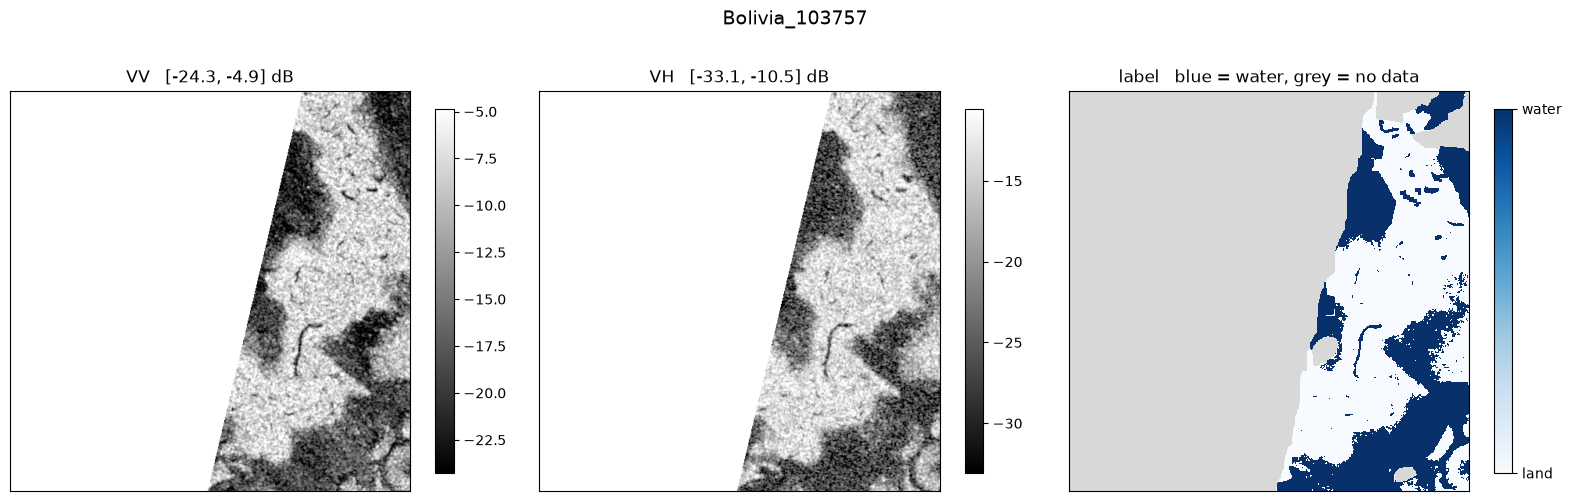

In [38]:
label_display = np.ma.masked_where(label == LABEL_NODATA, label)

fig, axes = plt.subplots(1, 3, figsize=(16, 5.5))

for ax, band, name in zip(axes[:2], (vv, vh), ("VV", "VH"), strict=True):
    vmin, vmax = percentile_limits(band)
    im = ax.imshow(band, cmap="gray", vmin=vmin, vmax=vmax)
    ax.set_title(f"{name}   [{vmin:.1f}, {vmax:.1f}] dB")
    fig.colorbar(im, ax=ax, shrink=0.75)

# interpolation="nearest" because the label is categorical
im = axes[2].imshow(label_display, cmap=LABEL_CMAP,
                    vmin=LABEL_LAND, vmax=LABEL_WATER, interpolation="nearest")
axes[2].set_title("label   blue = water, grey = no data")
cbar = fig.colorbar(im, ax=axes[2], shrink=0.75, ticks=[LABEL_LAND, LABEL_WATER])
cbar.ax.set_yticklabels([LABEL_NAMES[LABEL_LAND], LABEL_NAMES[LABEL_WATER]])

for ax in axes:
    ax.set_xticks([])
    ax.set_yticks([])

fig.suptitle(chip_id, fontsize=14)
fig.tight_layout()
plt.show()

Let's look at two other chips with the same issue. We start by loading them into Chip objects:

In [39]:
north, south = load_chip("Bolivia_360519"), load_chip("Bolivia_23014")

print(type(north), type(south))

<class 'aribu.dataset.Chip'> <class 'aribu.dataset.Chip'>


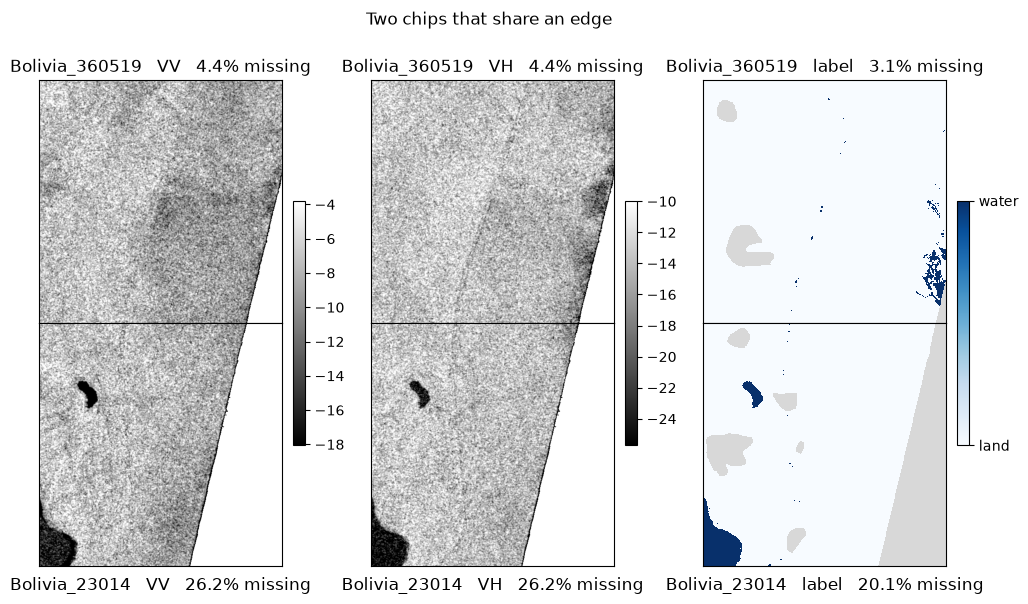

In [40]:
ref = south
vv_lo, vv_hi = percentile_limits(ref.vv)
vh_lo, vh_hi = percentile_limits(ref.vh)

fig, axes = plt.subplots(2, 3, figsize=(12, 6.2),
                         gridspec_kw={"hspace": 0.0, "wspace": 0.25,
                                      "top": 0.88, "bottom": 0.07})

for row, ((ax_vv, ax_vh, ax_label), chip) in enumerate(zip(axes, (north, south), strict=True)):
    im_vv = ax_vv.imshow(chip.vv, cmap="gray", vmin=vv_lo, vmax=vv_hi)
    im_vh = ax_vh.imshow(chip.vh, cmap="gray", vmin=vh_lo, vmax=vh_hi)

    label_display = np.ma.masked_where(chip.label == LABEL_NODATA, chip.label)
    im_label = ax_label.imshow(label_display, cmap=LABEL_CMAP,
                               vmin=LABEL_LAND, vmax=LABEL_WATER, interpolation="nearest")

    captions = (
        (ax_vv,    f"{chip.id}   VV   {np.isnan(chip.vv).mean():.1%} missing"),
        (ax_vh,    f"{chip.id}   VH   {np.isnan(chip.vh).mean():.1%} missing"),
        (ax_label, f"{chip.id}   label   "
                   f"{(chip.label == LABEL_NODATA).mean():.1%} missing"),
    )
    for ax, text in captions:
        if row == 0:
            ax.set_title(text)
        else:
            ax.set_xlabel(text, labelpad=8, fontsize=plt.rcParams["axes.titlesize"])

for ax in axes.flat:
    ax.set_xticks([])
    ax.set_yticks([])

fig.colorbar(im_vv, ax=axes[:, 0], shrink=0.75, fraction=0.046, pad=0.04)
fig.colorbar(im_vh, ax=axes[:, 1], shrink=0.75, fraction=0.046, pad=0.04)
cbar = fig.colorbar(im_label, ax=axes[:, 2], shrink=0.75, fraction=0.046, pad=0.04,
                    ticks=[LABEL_LAND, LABEL_WATER])
cbar.ax.set_yticklabels([LABEL_NAMES[LABEL_LAND], LABEL_NAMES[LABEL_WATER]])

for ax in axes[0]:
    ax.set_anchor("S")
for ax in axes[1]:
    ax.set_anchor("N")

fig.suptitle(f"Two chips that share an edge\n")
plt.show()

These two chips share an edge. 

A guess: most of the missing values mark the edge of what the satellite recorded on this pass, which runs at an angle to the chip grid.

## 3. Otsu on a chip

Let's load the first chip we looked at.

In [41]:
chip = load_chip("Mekong_922373")
vh = chip.vh
chip_id = chip.id
label = chip.label

valid = valid_mask(chip)

The distribution of the pixel values is bimodal, so `threshold_otsu` (a candidate for the baseline model) should a yield decent result:

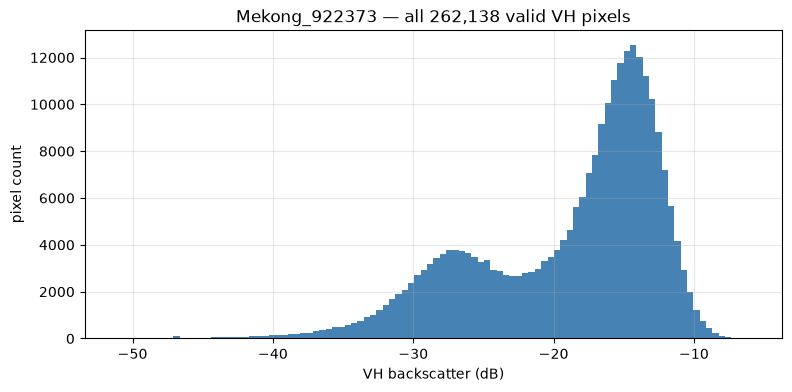

In [42]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(vh[valid], bins=100, color="steelblue", edgecolor="none")
ax.set_xlabel("VH backscatter (dB)")
ax.set_ylabel("pixel count")
ax.set_title(f"{chip_id} — all {vh[valid].size:,} valid VH pixels")
ax.grid(alpha=0.3)
plt.show()

water px: 119,765
land px: 142,373


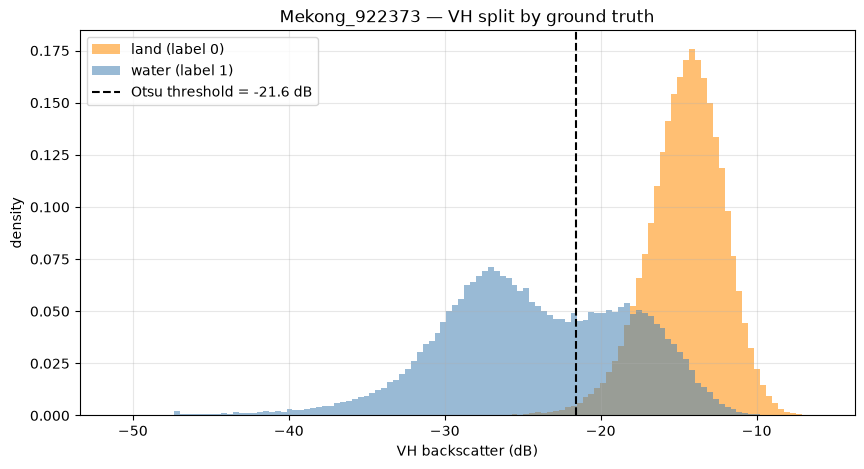

In [43]:
is_land  = valid & (chip.label == LABEL_LAND)
is_water = valid & (chip.label == LABEL_WATER)
print(f"water px: {is_water.sum():>7,}")
print(f"land px: {is_land.sum():>7,}")

bins = np.linspace(vh[valid].min(), vh[valid].max(), 120)

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(vh[is_land], bins=bins, alpha=0.55, density=True,
        color="darkorange", label="land (label 0)")
ax.hist(vh[is_water], bins=bins, alpha=0.55, density=True,
        color="steelblue", label="water (label 1)")

otsu_t = threshold_otsu(vh[valid])
ax.axvline(otsu_t, color="black", linestyle="--", linewidth=1.5,
           label=f"Otsu threshold = {otsu_t:.1f} dB")

ax.set_xlabel("VH backscatter (dB)")
ax.set_ylabel("density")
ax.set_title(f"{chip_id} — VH split by ground truth")
ax.legend()
ax.grid(alpha=0.3)
plt.show()

In [44]:
predicted_water = vh < otsu_t

tp = (predicted_water & is_water).sum()
fp = (predicted_water & is_land).sum()
fn = (~predicted_water & is_water).sum()
tn = (~predicted_water & is_land).sum()

print(f"true  positives (water, caught) : {tp:>7,}")
print(f"false positives (land, flagged) : {fp:>7,}")
print(f"false negatives (water, missed) : {fn:>7,}")
print(f"true  negatives (land, ignored) : {tn:>7,}")

print(f"\naccuracy : {(tp + tn) / valid.sum():.3f}")
print(f"precision: {tp / (tp + fp):.3f}")
print(f"recall   : {tp / (tp + fn):.3f}")
print(f"IoU      : {tp / (tp + fp + fn):.3f}")

true  positives (water, caught) :  76,524
false positives (land, flagged) :   1,221
false negatives (water, missed) :  43,241
true  negatives (land, ignored) : 141,152

accuracy : 0.830
precision: 0.984
recall   : 0.639
IoU      : 0.633


## 4. The dataset (S1)

In [45]:
splits = {name: read_split(name) for name in SPLIT_FILES}
chip_event = {c: c.rsplit("_", 1)[0] for v in splits.values() for c in v}
chip_split = {c: s for s, v in splits.items() for c in v}

for name, chips in splits.items():
    print(f"{name:<8} {len(chips):>4} chips   {len(set(chip_event[c] for c in chips)):>2} events")

all_chips = [c for chips in splits.values() for c in chips]
print(f"\ntotal {len(all_chips)}, unique {len(set(all_chips))}")

for a in splits:
    for b in splits:
        if a < b:
            overlap = set(splits[a]) & set(splits[b])
            assert not overlap, f"LEAKAGE: {a} and {b} share {len(overlap)} chips: {sorted(overlap)[:3]}"
print("no chip appears in two splits")

on_disk = {p.name.replace("_S1Hand.tif", "") for p in S1_DIR.glob("*_S1Hand.tif")}
assert set(all_chips) == on_disk, \
    f"split/disk mismatch: {len(set(all_chips) ^ on_disk)} chips differ"
print(f"the {len(on_disk)} chips on disk are exactly the {len(all_chips)} chips in the splits")

composition = (
    pd.DataFrame({"chip": all_chips})
    .assign(**{"event (from filename)": lambda d: d["chip"].map(chip_event),
               "split": lambda d: d["chip"].map(chip_split)})
    .pivot_table(index="event (from filename)", columns="split", aggfunc="size",
                 fill_value=0)
    .reindex(columns=list(SPLIT_ORDER), fill_value=0)
)
composition.loc["TOTAL"] = composition.sum()
print()
print(composition.to_string())

train     252 chips   10 events
val        89 chips   10 events
test       90 chips   10 events
bolivia    15 chips    1 events

total 446, unique 446
no chip appears in two splits
the 446 chips on disk are exactly the 446 chips in the splits

split                  train  val  test  bolivia
event (from filename)                           
Bolivia                    0    0     0       15
Ghana                     31   11    11        0
India                     40   14    14        0
Mekong                    18    6     6        0
Nigeria                   10    4     4        0
Pakistan                  16    6     6        0
Paraguay                  39   14    14        0
Somalia                   15    5     6        0
Spain                     18    6     6        0
Sri-Lanka                 24    9     9        0
USA                       41   14    14        0
TOTAL                    252   89    90       15


Eight chips to keep an eye on, spread across the events and both held-out splits. Section 5
comes back to exactly these, so it is worth seeing first what the radar makes of them.

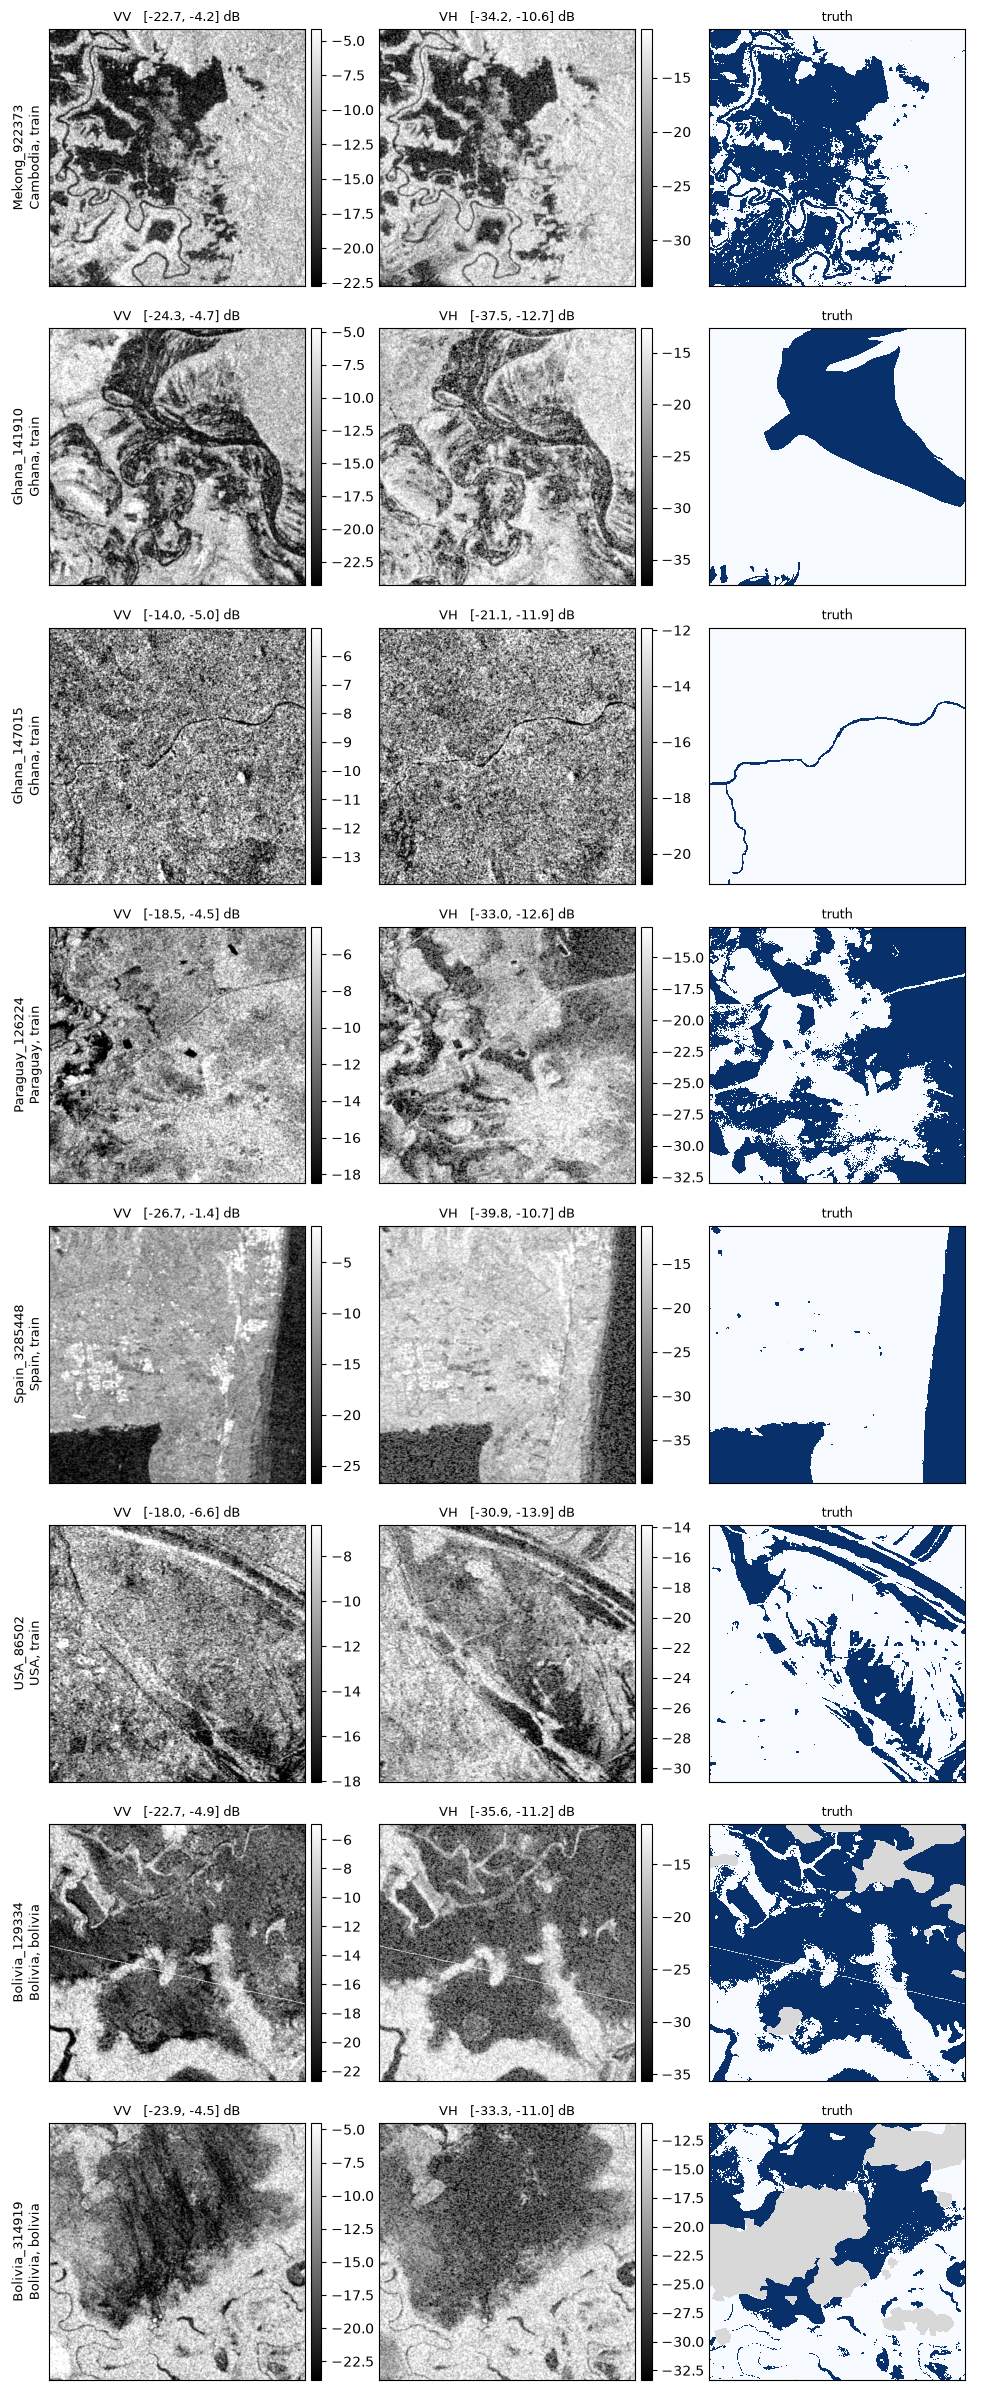

In [46]:
CHIPS = ["Mekong_922373", "Ghana_141910", "Ghana_147015", "Paraguay_126224", "Spain_3285448",
         "USA_86502", "Bolivia_129334", "Bolivia_314919"]

fig, axes = plt.subplots(len(CHIPS), 3, figsize=(10, 3.0 * len(CHIPS)))
for row, chip_id in zip(axes, CHIPS, strict=True):
    c = load_chip(chip_id)
    v = valid_mask(c)

    for ax, arr, title in zip(row, [c.vv, c.vh, np.ma.masked_where(~v, c.label == LABEL_WATER)],
                              ["VV", "VH", "truth"], strict=True):
        cax = make_axes_locatable(ax).append_axes("right", size="4%", pad=0.06)
        if title == "truth":
            ax.imshow(arr, cmap=LABEL_CMAP, vmin=0, vmax=1, interpolation="nearest")
            cax.axis("off")
        else:
            vmin, vmax = percentile_limits(arr)
            im = ax.imshow(arr, cmap="gray", vmin=vmin, vmax=vmax)
            fig.colorbar(im, cax=cax)
            title = f"{title}   [{vmin:.1f}, {vmax:.1f}] dB"
        ax.set(title=title, xticks=[], yticks=[])
        ax.title.set_fontsize(9)
    row[0].set_ylabel(f"{chip_id}\n{c.loc}, {chip_split[chip_id]}", fontsize=9)

fig.tight_layout()
plt.show()

## 5. The optical chips (S2)

There are also data from the Sentinel 2 optical satellite: every chip has 13 bands, including RGB, near-infrared (NIR), and shortwave-infrared (SWIR).

### 5.1 Inside an S2Hand file

In [47]:
chip_id = "Mekong_922373"
s2_path = S2_DIR / f"{chip_id}_S2Hand.tif"

with rasterio.open(s2_path) as src:
    print(f"bands:      {src.count}")
    print(f"dtypes:     {src.dtypes[0]}")
    print(f"shape:      {src.shape}      (rows, cols)")
    print(f"crs:        {src.crs}")
    print(f"nodata:     {src.nodata}")
    print(f"names:      {src.descriptions}")

print(f"\nB8A sits between B8 and B9, so B11 is band {S2_BANDS['B11']}, not 11")

bands:      13
dtypes:     int16
shape:      (512, 512)      (rows, cols)
crs:        EPSG:4326
nodata:     0.0
names:      ('B1', 'B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8', 'B8A', 'B9', 'B10', 'B11', 'B12')

B8A sits between B8 and B9, so B11 is band 12, not 11


- **B1**: coastal aerosol (443 nm)
- **B2**: blue (490 nm)
- **B3**: green (560 nm)
- **B4**: red (665 nm)
- **B5**: red edge 1 (705 nm)
- **B6**: red edge 2 (740 nm)
- **B7**: red edge 3 (783 nm)
- **B8**: near-infrared, NIR (842 nm)
- **B8A**: narrow NIR (865 nm)
- **B9**: water vapour (945 nm)
- **B10**: cirrus cloud (1375 nm)
- **B11**: shortwave-infrared 1, SWIR1 (1610 nm)
- **B12**: shortwave-infrared 2, SWIR2 (2190 nm)

### 5.2 Three ways to look at a chip

There are two standard water indices derived from green (B3), NIR (B8), and SWIR1 (B11) that will be important for our flood mapping project:

- **NDWI (Normalized Difference Water Index)** = (green - NIR) / (green + NIR)
- **MNDWI (Modified Normalized Difference Water Index)** = (green - SWIR1) / (green + SWIR1)

Water absorbs near-infrared and shortwave-infrared almost completely, so it is
dark in those bands while soil and vegetation stay bright; both ratios therefore read higher
over water than over land.

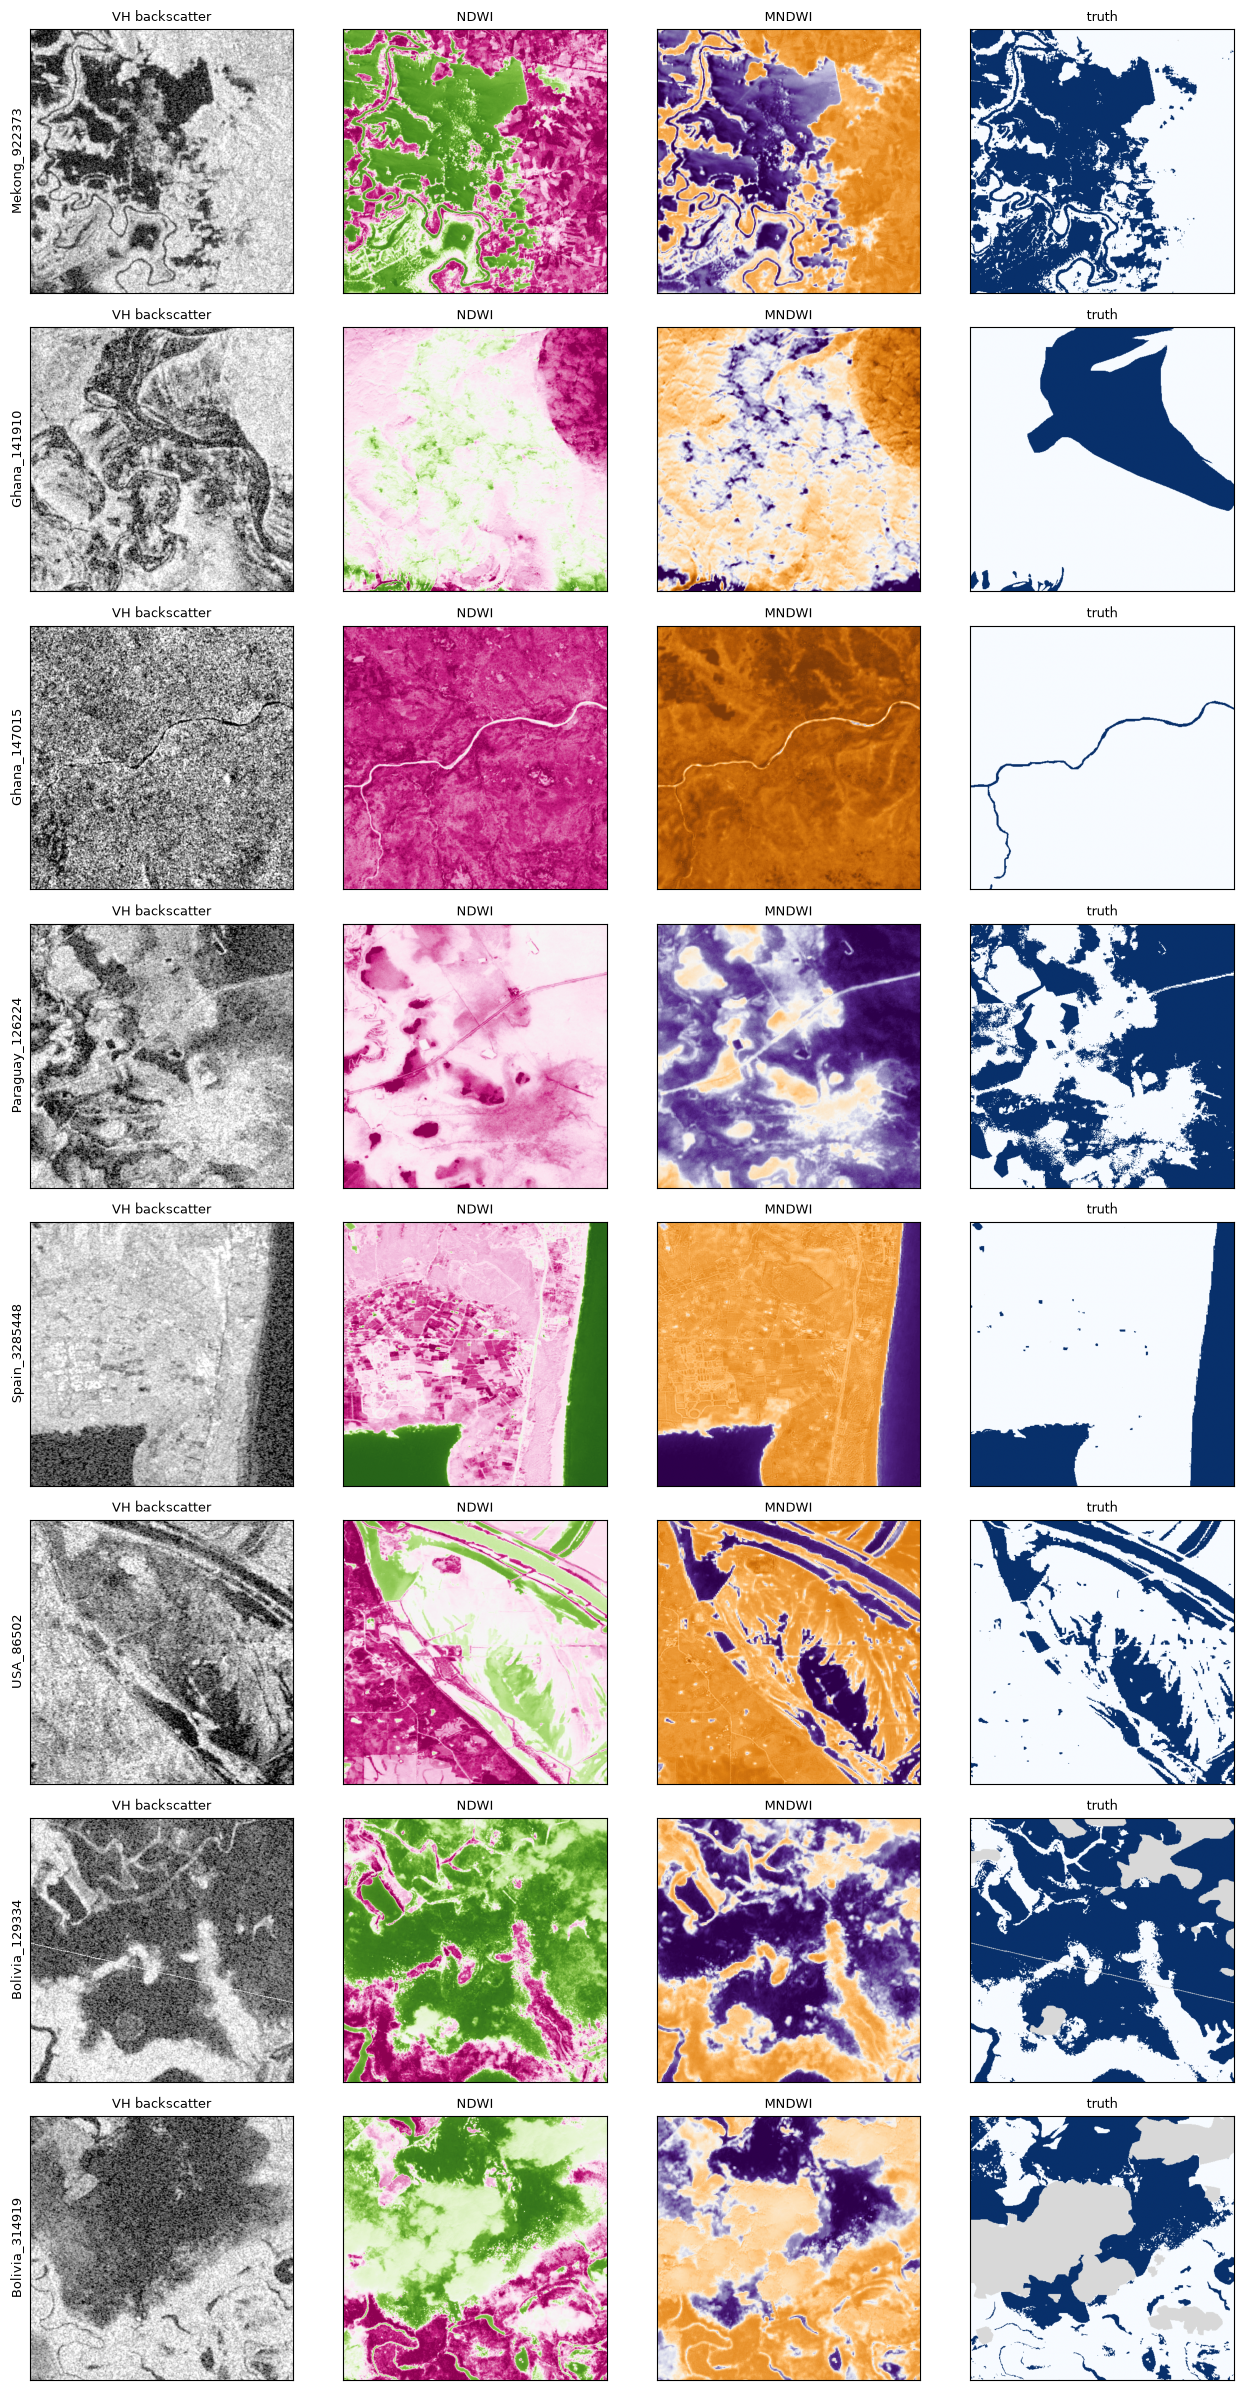

In [48]:
fig, axes = plt.subplots(len(CHIPS), 4, figsize=(13, 3.0 * len(CHIPS)))
for row, chip_id in zip(axes, CHIPS, strict=True):
    c, ind = load_chip(chip_id), water_indices(chip_id)
    v, water = valid_mask(c), c.label == LABEL_WATER

    for ax, arr, title in zip(row, [c.vh, ind[0], ind[1], np.ma.masked_where(~v, water)],
                              ["VH backscatter", "NDWI", "MNDWI", "truth"], strict=True):
        if title in INDEX_CMAPS:
            m = np.percentile(np.abs(arr), 98)
            ax.imshow(arr, cmap=INDEX_CMAPS[title], vmin=-m, vmax=m)
        else:
            lo, hi = percentile_limits(c.vh) if title != "truth" else (None, None)
            ax.imshow(arr, cmap="gray" if title != "truth" else LABEL_CMAP, vmin=lo, vmax=hi)
        ax.set(title=title, xticks=[], yticks=[])
        ax.title.set_fontsize(9)
    row[0].set_ylabel(chip_id, fontsize=9)

fig.tight_layout()
plt.show()